In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv


In [26]:
import pandas as pd
import numpy as np
df=pd.read_csv('/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv')


In [15]:
print(df.head(6))

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
5                    none          71             83             78  


In [10]:
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


In [11]:
print(df.shape)

(1000, 8)


In [12]:
print(df.dtypes)

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [17]:
df.isnull().sum()
df=df.dropna()
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


None of the columns has any missing values. I chose to drop them, as filling them might lead to inaccuracies.

In [19]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [22]:
df['race/ethnicity']=df['race/ethnicity'].str.lower()
df

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group b,bachelor's degree,standard,none,72,72,74
1,female,group c,some college,standard,completed,69,90,88
2,female,group b,master's degree,standard,none,90,95,93
3,male,group a,associate's degree,free/reduced,none,47,57,44
4,male,group c,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group e,master's degree,standard,completed,88,99,95
996,male,group c,high school,free/reduced,none,62,55,55
997,female,group c,high school,free/reduced,completed,59,71,65
998,female,group d,some college,standard,completed,68,78,77


In [24]:
df['total']=df.iloc[:,5:8].sum(axis=1)
df.sort_values('total',ascending=False).head(10)

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total
916,male,group e,bachelor's degree,standard,completed,100,100,100,300
962,female,group e,associate's degree,standard,none,100,100,100,300
458,female,group e,bachelor's degree,standard,none,100,100,100,300
114,female,group e,bachelor's degree,standard,completed,99,100,100,299
712,female,group d,some college,standard,none,98,100,99,297
179,female,group d,some high school,standard,completed,97,100,100,297
165,female,group c,bachelor's degree,standard,completed,96,100,100,296
625,male,group d,some college,standard,completed,100,97,99,296
685,female,group e,master's degree,standard,completed,94,99,100,293
903,female,group d,bachelor's degree,free/reduced,completed,93,100,100,293


In [26]:
df.groupby(['gender']).mean(numeric_only=True)

,math_score,reading_score,writing_score,total
gender,,,,
female,63.633205,72.608108,72.467181,208.708494
male,68.728216,65.473029,63.311203,197.512448


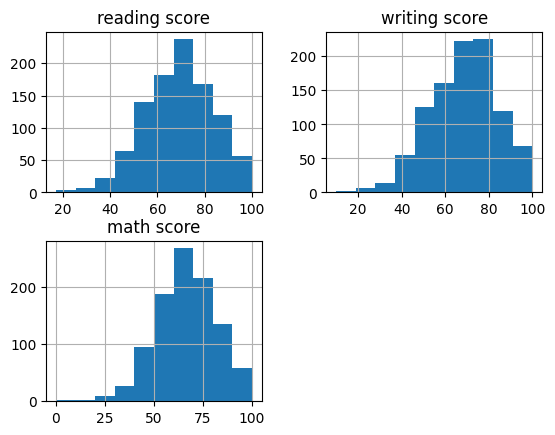

In [13]:
import matplotlib.pyplot as plt

df[["reading score","writing score","math score"]].hist()
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Overall Score Distribution")

plt.show()

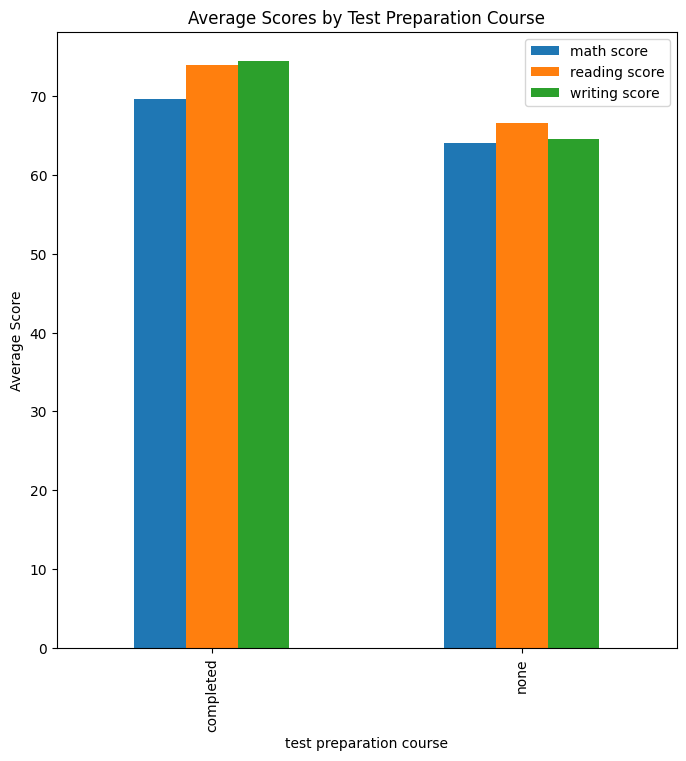

In [16]:
avg_scores = df.groupby("test preparation course")[["math score","reading score","writing score"]].mean()
avg_scores.plot(kind="bar", figsize=(8,8))

plt.ylabel("Average Score")
plt.title("Average Scores by Test Preparation Course")

plt.show()

1. The scores are roughly normally distributed, with scores ranging between 60 and 80 marks in each subject
2. The group which has completed the test preparation course seems to have done better than the group of students who did not


In [30]:
df["total_score"] = df["math score"] + df["reading score"] + df["writing score"]
df

,parental level of education,test preparation course,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,total_score
0,bachelor's degree,none,72,72,74,0,1,0,0,0,1,218
1,some college,completed,69,90,88,0,0,1,0,0,1,247
2,master's degree,none,90,95,93,0,1,0,0,0,1,278
3,associate's degree,none,47,57,44,1,0,0,0,0,0,148
4,some college,none,76,78,75,1,0,1,0,0,1,229
...,...,...,...,...,...,...,...,...,...,...,...,...
995,master's degree,completed,88,99,95,0,0,0,0,1,1,282
996,high school,none,62,55,55,1,0,1,0,0,0,172
997,high school,completed,59,71,65,0,0,1,0,0,0,195
998,some college,completed,68,78,77,0,0,0,1,0,1,223


The total score can help us analyse the overall academic performance of the student, rather than in each subject.

In [27]:
df = pd.get_dummies(df, columns=["gender", "race/ethnicity", "lunch"], drop_first=True, dtype=int)
df

,parental level of education,test preparation course,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard
0,bachelor's degree,none,72,72,74,0,1,0,0,0,1
1,some college,completed,69,90,88,0,0,1,0,0,1
2,master's degree,none,90,95,93,0,1,0,0,0,1
3,associate's degree,none,47,57,44,1,0,0,0,0,0
4,some college,none,76,78,75,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
995,master's degree,completed,88,99,95,0,0,0,0,1,1
996,high school,none,62,55,55,1,0,1,0,0,0
997,high school,completed,59,71,65,0,0,1,0,0,0
998,some college,completed,68,78,77,0,0,0,1,0,1


In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = ["math score","reading score","writing score","total_score"]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df

,parental level of education,test preparation course,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,total_score
0,bachelor's degree,none,0.72,0.662651,0.711111,0,1,0,0,0,1,0.699634
1,some college,completed,0.69,0.879518,0.866667,0,0,1,0,0,1,0.805861
2,master's degree,none,0.90,0.939759,0.922222,0,1,0,0,0,1,0.919414
3,associate's degree,none,0.47,0.481928,0.377778,1,0,0,0,0,0,0.443223
4,some college,none,0.76,0.734940,0.722222,1,0,1,0,0,1,0.739927
...,...,...,...,...,...,...,...,...,...,...,...,...
995,master's degree,completed,0.88,0.987952,0.944444,0,0,0,0,1,1,0.934066
996,high school,none,0.62,0.457831,0.500000,1,0,1,0,0,0,0.531136
997,high school,completed,0.59,0.650602,0.611111,0,0,1,0,0,0,0.615385
998,some college,completed,0.68,0.734940,0.744444,0,0,0,1,0,1,0.717949


Scaling ensures, that not only the value with the largest range, but all categories are considered equally. It also ensures faster training.

In [40]:
df.to_csv('processed.csv', index=False)